<p align="center">
<a href="https://colab.research.google.com/github/md-ryhan-uddin/ai-lab-experiments/blob/main/experiment_07.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<a href="https://kaggle.com/kernels/welcome?src=https://github.com/md-ryhan-uddin/ai-lab-experiments/blob/main/experiment_07.ipynb">
    <img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Open In Kaggle" height="20"/>
</a>
</p>

## **Experiment 07:** Training and Performance Analysis of Feedforward Neural Networks using the Backpropagation Algorithm

**Course:** ICE 4111: Artificial Intelligence Lab  
**Program:** Bachelor of Science in Information and Communication Engineering (BSc in ICE)  
**Instructor:** Md. Ryhan Uddin

**Student Name:** ______________________________  
**Student ID:** ______________________________  
**Section/Batch:** ______________________________  
**Date of Submission:** ______________________________  


### **Quick Overview**

In this experiment, a feedforward neural network is trained on the **Wine dataset** using backpropagation. You will change the dataset, hidden-layer sizes, neuron counts, and training hyperparameters, then evaluate the model using learning curves, a classification report, a confusion matrix, per-class accuracy, and sample predictions. All metric values are generated by your own Colab run; do not copy expected or invented accuracy values.


### **Learning Objectives**

After completing this experiment, students will be able to:

- Train a feedforward neural network for multiclass classification using backpropagation.
- Apply the Adam optimizer and early stopping to a training loop.
- Monitor training and validation curves to diagnose underfitting and overfitting.
- Evaluate a multiclass model using accuracy, a classification report, and a confusion matrix.
- Visually inspect correctly and incorrectly classified samples to understand model behavior.


## **Theory**

### Introduction

A feedforward neural network passes information from the input layer through one or more hidden layers to the output layer without cycles. Training uses the **backpropagation algorithm** to compute how each weight contributes to the final error, and a gradient-based optimizer then updates the weights to reduce that error. This experiment focuses on the learning process itself — how loss and accuracy evolve over epochs — which is central to all modern deep learning systems.

### Mathematical Background

If the loss function is $L(\hat{y}, y)$ and the network output is obtained by composing layers, backpropagation uses the chain rule to compute gradients such as $\partial L / \partial W$. For a layer $z = Wa + b$ with activation $a' = \phi(z)$, the gradient of the loss is propagated backward from the output layer to earlier layers:

$$\frac{\partial L}{\partial W} = \frac{\partial L}{\partial a'} \cdot \frac{\partial a'}{\partial z} \cdot \frac{\partial z}{\partial W}$$

For multiclass classification, the output layer uses a **softmax** activation

$$\hat{y}_k = \frac{e^{z_k}}{\sum_{j} e^{z_j}}$$

so that the outputs form a probability distribution over all classes, and the network is trained with **categorical cross-entropy loss**:

$$L = -\sum_{k=1}^{K} y_k \log(\hat{y}_k)$$

Gradient-based optimizers such as Adam then update the parameters using the computed derivatives, combining momentum with per-parameter adaptive learning rates.

### Important Concepts

The practical training loop is: initialize weights, perform forward propagation, compute the loss, backpropagate gradients, update weights, and repeat for many epochs. **Early stopping** halts training when validation performance no longer improves for a set number of epochs (patience), and restores the weights from the best epoch. In a feedforward network, hidden layers learn intermediate representations that can be more useful for classification than the raw input features alone — this is one reason deep networks generalize better than a single linear layer on many multiclass tasks.

Labels for multiclass problems are converted to **one-hot vectors** (e.g. digit `3` becomes `[0,0,0,1,0,0,0,0,0,0]`) so they can be compared directly against the softmax output using categorical cross-entropy.

### Advantages and Applications

**Advantages**

- Feedforward networks are easy to build and are a strong baseline for classification problems.
- Backpropagation scales efficiently to networks with many layers and parameters.
- Hidden layers learn useful intermediate features automatically, without manual feature engineering.

**Disadvantages**

- Feedforward networks are less effective than specialized architectures (CNNs for images, RNNs/Transformers for sequences) because they ignore spatial or temporal structure.
- Training is sensitive to hyperparameters such as learning rate, layer sizes, and initialization.

**Applications**

Feedforward networks remain important as baselines and as building blocks inside larger systems, and are directly useful for tabular data classification, simple pattern recognition, and — as in this lab — recognizing small, low-resolution images such as handwritten digits.

```mermaid
flowchart LR
    A[Input Layer: 64 Pixels] --> B[Hidden Layer 1: ReLU]
    B --> C[Hidden Layer 2: ReLU]
    C --> D[Output Layer: Softmax]
    D --> E[Categorical Cross-Entropy Loss]
    E --> F[Backpropagation]
    F --> B
    F --> C
```


## **Required Software and Libraries**

Install or prepare the following before starting the lab:

- Python 3.12 or later
- Jupyter Notebook, JupyterLab, VS Code, or Google Colab
- NumPy
- Pandas
- Matplotlib
- TensorFlow 2.x / Keras
- Scikit-learn

### Starter Check

Run the first code cell (library imports and setup). If it prints `Setup complete. You can start the experiment.`, your environment is ready.

## **Dataset Description**

This modified experiment uses the **Wine dataset** from Scikit-learn.

- **Samples:** 178 wine samples.
- **Input features:** 13 numeric chemical measurements per sample.
- **Target labels:** 3 wine classes (0, 1, and 2).
- **Source:** `sklearn.datasets.load_wine`.
- **Preprocessing:** Standardize features using `StandardScaler`; labels are one-hot encoded for the softmax output.
- **Reason for selection:** It is a small multiclass dataset that lets us change the input size and output neurons while retaining the feedforward/backpropagation experiment.


## **Experimental Procedure**

1. Load the Wine dataset and standardize its 13 input features.
2. One-hot encode the three target classes.
3. Split the data into training, validation, and test sets.
4. Build a feedforward network with two hidden layers (32 and 16 neurons) and a 3-neuron softmax output.
5. Train using Adam, backpropagation, and early stopping.
6. Record the model summary, test accuracy, classification report, and plots.
7. Use the actual outputs from your Colab run in the lab report; results can vary with changes to parameters or software versions.


## **Source Code**

Run the following cells one by one. Read the output after each cell and add comments in your own words where instructed by your teacher.

**Tip:** Do not only run the notebook. Try changing the number of hidden units, the activation function, or the batch size, and observe how the learning curves and confusion matrix change.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Fixed seeds make runs more reproducible.
tf.keras.utils.set_random_seed(42)
np.random.seed(42)
tf.get_logger().setLevel("ERROR")
plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

print("Setup complete. You can start the experiment.")


Setup complete. You can start the experiment.


In [2]:
# Load Wine dataset, standardize features, and encode class labels
wine = load_wine()
X_raw = wine.data.astype("float32")
y = wine.target.astype("int64")

# Split first, then fit scaler only on training data to avoid data leakage.
X_train_full_raw, X_test_raw, y_train_full_int, y_test_int = train_test_split(
    X_raw, y, test_size=0.20, random_state=42, stratify=y
)
X_train_raw, X_val_raw, y_train_int, y_val_int = train_test_split(
    X_train_full_raw, y_train_full_int, test_size=0.20,
    random_state=42, stratify=y_train_full_int
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw).astype("float32")
X_val = scaler.transform(X_val_raw).astype("float32")
X_test = scaler.transform(X_test_raw).astype("float32")
y_train = tf.keras.utils.to_categorical(y_train_int, num_classes=3)
y_val = tf.keras.utils.to_categorical(y_val_int, num_classes=3)
y_test = tf.keras.utils.to_categorical(y_test_int, num_classes=3)

print("Full dataset shape:", X_raw.shape)
print("Number of features:", X_raw.shape[1])
print("Class counts:", np.bincount(y))
print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)
print("Standardized training feature mean (approx. 0):", round(float(X_train.mean()), 4))


Full dataset shape: (178, 13)
Number of features: 13
Class counts: [59 71 48]
Training shape: (113, 13)
Validation shape: (29, 13)
Test shape: (36, 13)
Standardized training feature mean (approx. 0): -0.0


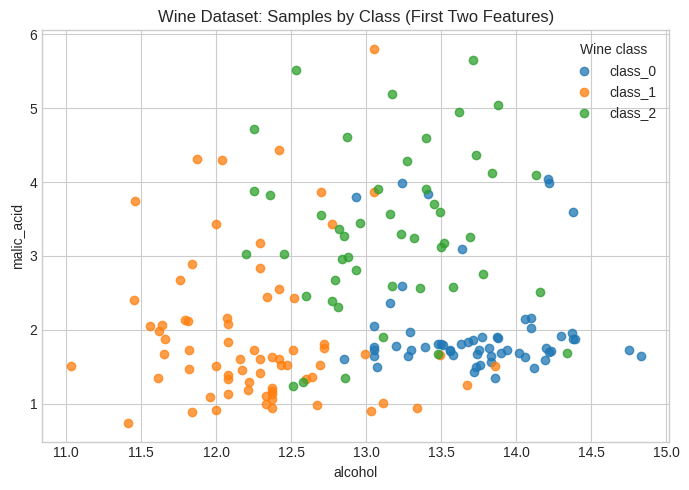

In [3]:
# Visualize samples using the first two standardized features
plt.figure(figsize=(7, 5))
for class_id, class_name in enumerate(wine.target_names):
    mask = y == class_id
    plt.scatter(X_raw[mask, 0], X_raw[mask, 1], label=class_name, alpha=0.75)
plt.xlabel(wine.feature_names[0])
plt.ylabel(wine.feature_names[1])
plt.title("Wine Dataset: Samples by Class (First Two Features)")
plt.legend(title="Wine class")
plt.tight_layout()
plt.show()


In [4]:
# Train / Validation / Test split sizes were created in the preprocessing cell
print("Train shape     :", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape      :", X_test.shape)


Train shape     : (113, 13)
Validation shape: (29, 13)
Test shape      : (36, 13)


In [5]:
# Build a modified Feedforward Neural Network
# Changed hidden neurons: 32 and 16; output neurons: 3 classes.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax"),
])

# Changed learning rate from 0.001 to 0.005
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

# Take a screenshot of this output for the Model Summary part of Results.
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,027 (4.01 KB)

 Trainable params: 1,027 (4.01 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train the Network with Backpropagation and Early Stopping
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,          # changed from 50
    batch_size=16,      # changed from 32
    verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=8, restore_best_weights=True
    )],
)
print(f"Training finished after {len(history.history['loss'])} epochs.")


Epoch 1/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 214ms/step - accuracy: 0.4248 - loss: 1.1172 - val_accuracy: 0.7241 - val_loss: 0.8156
Epoch 2/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.8142 - loss: 0.6506 - val_accuracy: 0.8966 - val_loss: 0.5504
Epoch 3/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9381 - loss: 0.4110 - val_accuracy: 0.8621 - val_loss: 0.3871
Epoch 4/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9646 - loss: 0.2574 - val_accuracy: 0.8966 - val_loss: 0.2779
Epoch 5/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9912 - loss: 0.1599 - val_accuracy: 0.9310 - val_loss: 0.2102
Epoch 6/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9912 - loss: 0.1017 - val_accuracy: 0.9310 - val_loss: 0.1728
Epoch 7/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9912 - loss: 0.0672 - val_accuracy: 0.9310 - val_loss: 0.1599
Epoch 8/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9912 - loss: 0.0459 - val_accuracy: 0.9310 - val_loss: 0.1551

In [7]:
# Evaluate on the held-out Test Set
test_probabilities = model.predict(X_test, verbose=0)
test_predictions = np.argmax(test_probabilities, axis=1)
test_true = y_test_int

test_accuracy = accuracy_score(test_true, test_predictions)
print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(
    test_true, test_predictions,
    labels=[0, 1, 2], target_names=list(wine.target_names), zero_division=0
))


Test Accuracy: 0.9722

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



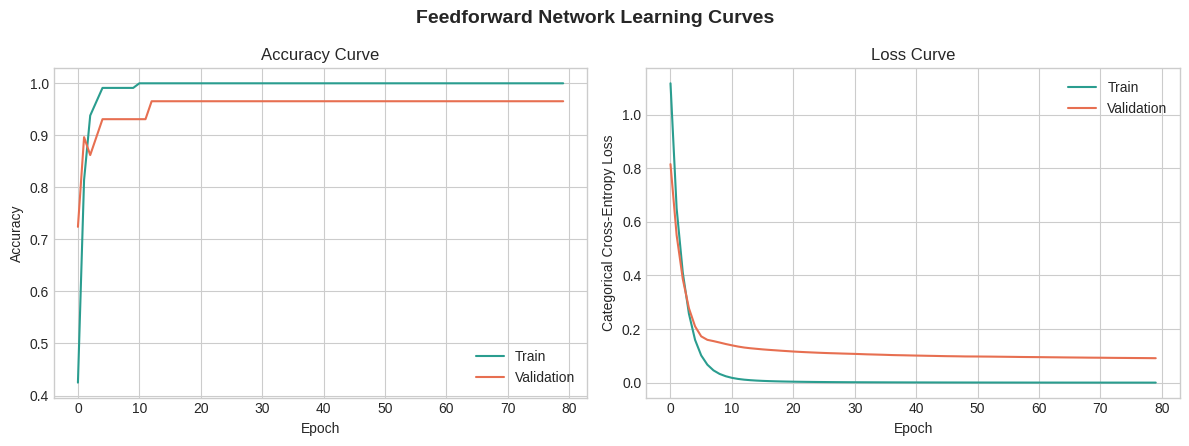

In [8]:
# Training vs Validation Accuracy and Loss Curves

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history.history["accuracy"], label="Train", color="#2a9d8f")
axes[0].plot(history.history["val_accuracy"], label="Validation", color="#e76f51")
axes[0].set_title("Accuracy Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train", color="#2a9d8f")
axes[1].plot(history.history["val_loss"], label="Validation", color="#e76f51")
axes[1].set_title("Loss Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Categorical Cross-Entropy Loss")
axes[1].legend()

plt.suptitle("Feedforward Network Learning Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

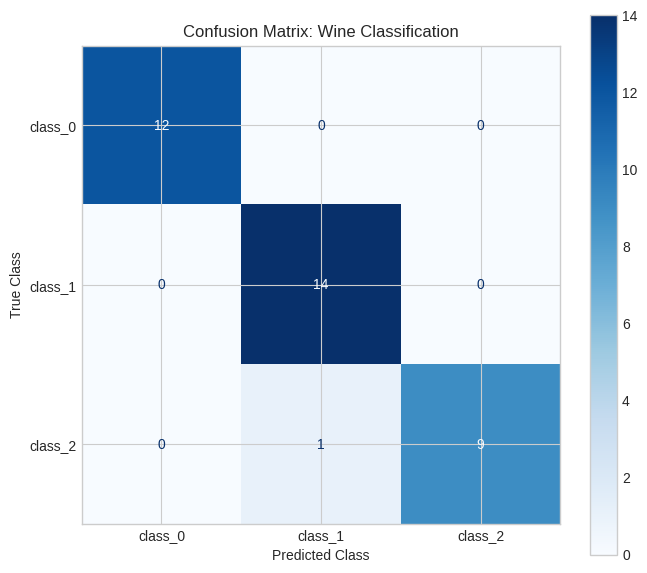

In [9]:
# Confusion Matrix
cm = confusion_matrix(test_true, test_predictions, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(wine.target_names))
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap="Blues", ax=ax, colorbar=True, values_format="d")
plt.title("Confusion Matrix: Wine Classification")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()


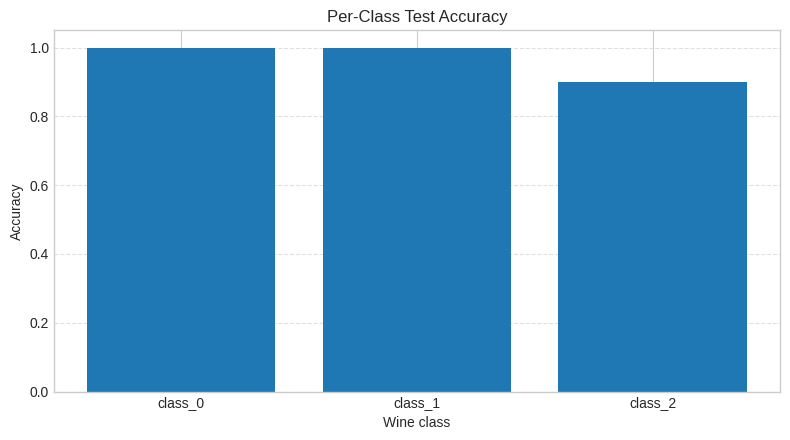

In [10]:
# Per-Class Test Accuracy
per_class_accuracy = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)
plt.figure(figsize=(8, 4.5))
plt.bar(wine.target_names, per_class_accuracy)
plt.xlabel("Wine class")
plt.ylabel("Accuracy")
plt.title("Per-Class Test Accuracy")
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


Correctly classified: 35 / 36
Misclassified: 1 / 36


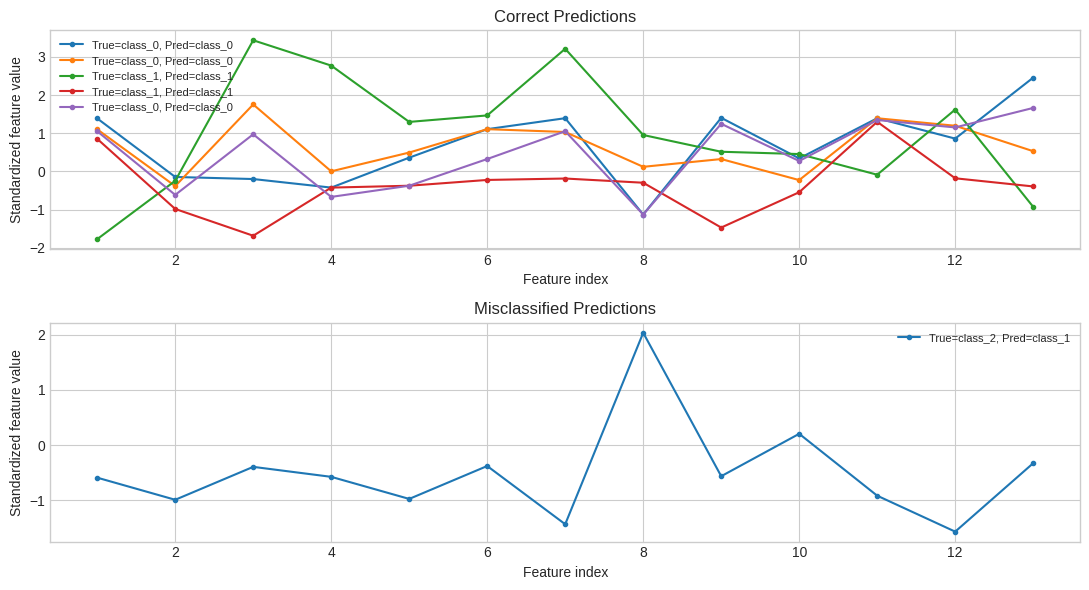

In [11]:
# Inspect correctly and incorrectly classified test samples
correct = np.where(test_predictions == test_true)[0]
misclassified = np.where(test_predictions != test_true)[0]
print(f"Correctly classified: {len(correct)} / {len(test_true)}")
print(f"Misclassified: {len(misclassified)} / {len(test_true)}")

# Show the first five correct and incorrect test cases as feature-value plots.
fig, axes = plt.subplots(2, 1, figsize=(11, 6))
for row, (indices, title) in enumerate([
    (correct[:5], "Correct Predictions"),
    (misclassified[:5], "Misclassified Predictions")
]):
    ax = axes[row]
    if len(indices) == 0:
        ax.text(0.5, 0.5, "No samples in this group", ha="center", va="center")
        ax.set_axis_off()
        continue
    for idx in indices:
        ax.plot(np.arange(1, X_test.shape[1] + 1), X_test[idx], marker=".",
                label=f"True={wine.target_names[test_true[idx]]}, Pred={wine.target_names[test_predictions[idx]]}")
    ax.set_title(title)
    ax.set_xlabel("Feature index")
    ax.set_ylabel("Standardized feature value")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## **Expected Outputs**

Your own Colab run will produce dataset/split shapes, a dataset scatter plot, the model summary, training duration, test accuracy, classification report, accuracy/loss curves, confusion matrix, per-class accuracy chart, and sample prediction plots. **Do not write a guessed accuracy in the report; copy the value printed by your own run.**


## **Performance Evaluation**

Evaluate the model using the test accuracy and class-wise precision, recall, and F1-score. Compare training and validation curves: a widening accuracy gap or validation loss that rises while training loss falls can indicate overfitting. The confusion matrix shows which wine classes are correctly or incorrectly predicted. Record the values from your actual output.


## **Discussion**

The Wine dataset has 13 numeric input features and three target classes, so the output layer uses three softmax neurons. The hidden layers use 32 and 16 neurons, and the Adam learning rate is set to 0.005. StandardScaler is fitted only on the training data to avoid leaking information from the validation/test sets. Discuss the test accuracy and the plots based on the results produced by your own Colab run; do not assume a particular score before running the code.


## **Viva Questions**

1. **Q:** What is a feedforward neural network?  
   **A:** A network where data flows from the input layer to the output layer through one or more hidden layers without cycles.

2. **Q:** What does backpropagation compute?  
   **A:** The gradients of the loss with respect to every weight in the network, using the chain rule.

3. **Q:** Why is the Adam optimizer popular?  
   **A:** It combines momentum with adaptive, per-parameter learning rates, which usually leads to fast and stable convergence.

4. **Q:** What is the purpose of an activation function such as ReLU?  
   **A:** To introduce non-linearity, allowing the network to model complex relationships instead of only linear ones.

5. **Q:** Why is one-hot encoding used for the labels here?  
   **A:** Because the output layer uses softmax with categorical cross-entropy, which compares a probability distribution against a one-hot target vector.

6. **Q:** What is early stopping, and why use it?  
   **A:** Stopping training when validation performance stops improving for a set number of epochs, to prevent overfitting and save training time.

7. **Q:** Why is the Digits dataset useful for this experiment?  
   **A:** It is small, requires no download, and is well suited to demonstrating multiclass feedforward training quickly.

8. **Q:** What is the role of the hidden layers?  
   **A:** To learn intermediate feature representations from the raw pixel input that make the classes easier to separate.

9. **Q:** What does a rising validation loss alongside falling training loss indicate?  
   **A:** Overfitting — the model is fitting the training data at the expense of generalization.

10. **Q:** Why is a confusion matrix useful beyond overall accuracy?  
    **A:** It shows exactly which classes are being confused with each other, which a single accuracy number cannot reveal.

## **Exercises / Parameter Changes**

1. Change hidden-layer neurons from 32/16 to 64/32 and compare the actual test accuracy.
2. Try `tanh` instead of `relu` in both hidden layers.
3. Add a `Dropout(0.2)` layer after a hidden layer and compare the learning curves.
4. Change the learning rate from `0.005` to `0.001` and compare convergence.
5. Change the batch size from `16` to `32` and compare the results.

## **Lab Report: Results Section and Screenshot Checklist**

Take screenshots **after running the corresponding cell**. Use the real outputs from your own run.

1. **Dataset and preprocessing:** screenshot the output of the dataset cell showing dataset shape, feature count, class counts, and split sizes. Also capture the Wine dataset scatter plot.
2. **Model summary:** screenshot the complete output directly below `model.summary()` (layer names, output shapes, and parameter counts).
3. **Training:** screenshot the training output showing the final epoch/early-stopping duration. This is optional if the report is too long.
4. **Evaluation:** screenshot the test accuracy and complete classification report together if visible; otherwise take two screenshots.
5. **Learning curves:** screenshot the combined training/validation accuracy and loss graphs.
6. **Confusion matrix:** screenshot the full confusion matrix with all three class labels and values visible.
7. **Per-class accuracy:** screenshot the bar chart.
8. **Prediction inspection:** screenshot the correct/misclassified prediction plots.

### Suggested Results subsection order

- **Result 1: Dataset and preprocessing output** — state the observed data dimensions and split sizes.
- **Result 2: Model summary** — describe the two hidden layers (32 and 16 neurons) and the three-neuron output layer. Use the parameter count shown by Keras.
- **Result 3: Training and test performance** — report the actual test accuracy and classification-report metrics.
- **Result 4: Learning curves** — explain whether training and validation curves are close or show a gap.
- **Result 5: Confusion matrix and per-class accuracy** — identify the classes with the most correct predictions/errors based on your plots.
- **Result 6: Prediction examples** — briefly explain what the correct/misclassified examples show.

**Important:** The model's accuracy, parameter count, training epochs, and class-wise metrics must come from your Colab output. They are not fixed in advance and should not be invented.

## **Lab Report Submission Checklist**

- Cover information completed.
- Objective and theory summary.
- Dataset description and preprocessing output.
- Model summary screenshot.
- Test accuracy and classification report.
- Accuracy/loss curves, confusion matrix, per-class accuracy chart, and prediction plots.
- Short discussion based on the actual plots and metrics.
- Answers to assigned viva questions.
- Brief comparison after changing one or more parameters.
